In [1]:
import os

data_path = "../data"

print(os.listdir(data_path))

['ChestXray_Classification']


In [2]:
for root, dirs, files in os.walk(data_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

../data
Folders: ['ChestXray_Classification']
Files: []
--------------------------------------------------
../data\ChestXray_Classification
Folders: ['ChestXray_Classification']
Files: []
--------------------------------------------------
../data\ChestXray_Classification\ChestXray_Classification
Folders: ['test', 'train', 'valid']
Files: []
--------------------------------------------------
../data\ChestXray_Classification\ChestXray_Classification\test
Folders: ['0', '1']
Files: []
--------------------------------------------------
../data\ChestXray_Classification\ChestXray_Classification\test\0
Folders: []
Files: ['019456d451d855736ae5c32e2484a100.jpg', '019668dbdc511714d119c10b87dca089.jpg', '049223b782fa4f7ca4f4f1f175fc9fd9.jpg', '07011dce1196d722a672c30918252dea.jpg', '07721069d7590cdac4891353316ed6c9.jpg']
--------------------------------------------------
../data\ChestXray_Classification\ChestXray_Classification\test\1
Folders: []
Files: ['00150343289f317a0ad5629d5b7d9ef9.jpg', '

In [3]:
import os

base_path = "../data/ChestXray_Classification/ChestXray_Classification"

for split in ["train", "valid", "test"]:
    print(f"\n{split.upper()} SET")
    
    for label in ["0", "1"]:
        folder = os.path.join(base_path, split, label)
        count = len(os.listdir(folder))
        
        print(f"Class {label}: {count} images")


TRAIN SET
Class 0: 4277 images
Class 1: 4277 images

VALID SET
Class 0: 535 images
Class 1: 535 images

TEST SET
Class 0: 535 images
Class 1: 535 images


## Class Distribution Analysis

The dataset is perfectly balanced across all splits (train, validation, and test). 

Both classes contain equal numbers of samples:
- Train: 4277 images per class
- Validation: 535 images per class
- Test: 535 images per class

This balanced distribution reduces the risk of model bias toward a specific class and simplifies the training process.

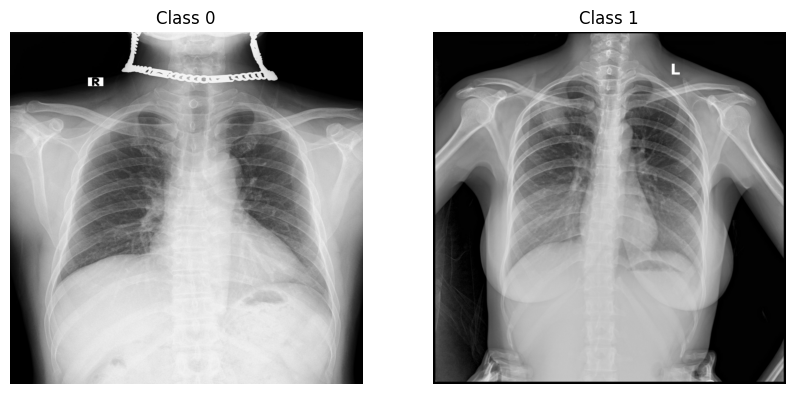

In [4]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,5))

labels = ["0", "1"]

for i, label in enumerate(labels):
    
    img_path = os.path.join(
        base_path,
        "train",
        label,
        os.listdir(os.path.join(base_path, "train", label))[0]
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"Class {label}")
    axes[i].axis("off")

plt.show()

## Sample Image Visualization

Sample chest X-ray images from both classes were visualized to better understand the dataset characteristics.

Observations:
- Images are grayscale chest X-rays.
- Image brightness and contrast vary between samples.
- Some images contain visible artifacts and markers.
- The dataset appears suitable for preprocessing techniques such as normalization and CLAHE enhancement.

In [5]:
image_sizes = []

for label in ["0", "1"]:
    
    folder = os.path.join(base_path, "train", label)
    
    for img_name in os.listdir(folder)[:100]:
        
        img_path = os.path.join(folder, img_name)
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        image_sizes.append(img.shape)

print("First 10 image sizes:")
print(image_sizes[:10])

print("\nUnique image sizes:")
print(set(image_sizes))

First 10 image sizes:
[(1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024)]

Unique image sizes:
{(1024, 1024)}


## Image Resolution Analysis

All images in the dataset have a consistent resolution of 1024×1024 pixels.

This standardized image size simplifies preprocessing and model training processes since no additional resizing consistency checks are required.

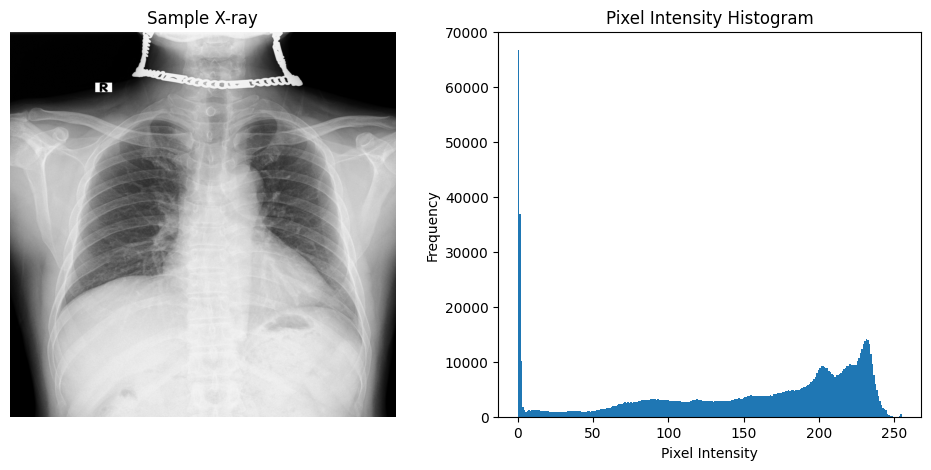

In [6]:
sample_image_path = os.path.join(
    base_path,
    "train",
    "0",
    os.listdir(os.path.join(base_path, "train", "0"))[0]
)

img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,5))

# Image
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Sample X-ray")
plt.axis("off")

# Histogram
plt.subplot(1,2,2)
plt.hist(img.ravel(), bins=256)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

## Histogram Analysis

Pixel intensity histogram analysis was performed to examine the brightness and contrast distribution of chest X-ray images.

Observations:
- A significant number of pixels are concentrated near zero intensity values, representing the dark background regions.
- Most anatomical information is distributed across medium and high intensity ranges.
- The intensity distribution indicates varying contrast levels, suggesting that contrast enhancement techniques such as CLAHE may improve feature visibility.

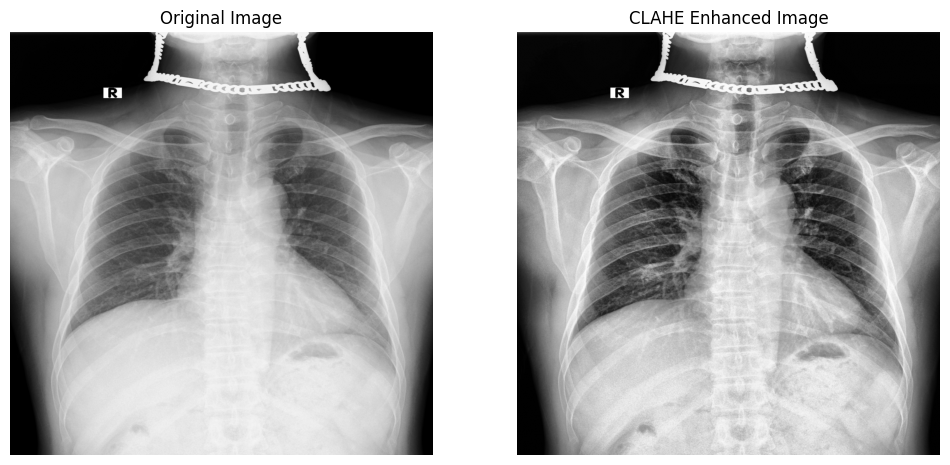

In [7]:
# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

# Apply CLAHE
clahe_img = clahe.apply(img)

# Show comparison
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Enhanced Image")
plt.axis("off")

plt.show()

## CLAHE Enhancement

Contrast Limited Adaptive Histogram Equalization (CLAHE) was applied to improve local contrast in chest X-ray images.

Observations:
- Lung structures and anatomical details became more visible after enhancement.
- Local contrast improved significantly, especially in darker regions.
- CLAHE may help the deep learning model learn subtle pathological patterns more effectively.
- Slight noise amplification was also observed, which is a common side effect of contrast enhancement techniques.